# Mundialito — Tablas de estadísticas
## Proyecto 1, Opción A — Cálculo Multivariable (UFM)

Simulación de un mundial de **16 equipos reales** repartidos en **4 grupos** (A, B, C, D),
con **jugadores inventados**. Los partidos se simulan al azar con `numpy.random`: en cada
partido ambos equipos tienen la **misma probabilidad de ganar**, así que cualquier equipo
puede salir campeón.

Se registran marcadores, goleadores, asistencias y goles recibidos por cada portero. Al
final de cada jornada y de cada fase eliminatoria se despliegan todas las tablas, y al final
el usuario puede **consultar** la tabla que desee en la fase que desee.

In [ ]:
# Importamos las librerías que usamos en clase
import numpy as np                      # NumPy para los números aleatorios y la gráfica
import matplotlib.pyplot as plt         # Matplotlib para la gráfica de goleadores
from tabulate import tabulate           # tabulate para imprimir las tablas con bordes

# No fijamos semilla a propósito: así cada vez que se corre el notebook sale un mundial diferente

## 1. Datos: equipos y jugadores
16 equipos reales en 4 grupos. Cada equipo tiene 6 jugadores inventados (un portero y cinco
de campo) con su nombre y su posición (POR = portero, DEF = defensa, MED = mediocampista,
DEL = delantero).

In [4]:
# Definimos los 16 equipos reales repartidos en 4 grupos
grupos = {                                                                                      # diccionario de grupos
    'A': ['Argentina', 'Portugal', 'España', 'Brasil'],                                          # equipos del Grupo A
    'B': ['Cabo Verde', 'Francia', 'San Marino', 'URSS'],                                        # equipos del Grupo B
    'C': ['Yugoslavia', 'Imperio Otomano', 'Imperio Romano', 'Rep. Río de la Plata'],            # equipos del Grupo C
    'D': ['Guatemala', 'Belice', 'El Vaticano', 'Imperio Mongol'],                               # equipos del Grupo D
}                                                                                               # fin del diccionario de grupos

In [5]:
# Definimos la plantilla inventada de cada equipo como [nombre, posición]
jugadores = {                                                  # diccionario con todos los jugadores
    'Argentina':            [['Ramiro Vena','POR'],['Lautaro Gómez','DEF'],['Bruno Quiroga','DEF'],['Tomás Aguirre','MED'],['Iván Sosa','MED'],['Marco Fariña','DEL']],          # plantilla de Argentina
    'Portugal':             [['Rui Tavares','POR'],['Diogo Nunes','DEF'],['Tiago Brito','DEF'],['Nuno Sá','MED'],['André Pinto','MED'],['Gonçalo Reis','DEL']],                  # plantilla de Portugal
    'España':               [['Aitor Vidal','POR'],['Sergio Lama','DEF'],['Hugo Bravo','DEF'],['Marc Sáez','MED'],['Pablo Nieto','MED'],['Iker Mendoza','DEL']],                 # plantilla de España
    'Brasil':               [['Wesley Lima','POR'],['Caio Souza','DEF'],['Rafael Pinto','DEF'],['Bruno Alves','MED'],['Diego Rocha','MED'],['Vinícius Melo','DEL']],             # plantilla de Brasil
    'Cabo Verde':           [['Nilton Tavares','POR'],['Edmilson Brito','DEF'],['Gérson Lopes','DEF'],['Djaniny Moreno','MED'],['Kévin Andrade','MED'],['Zé Fortes','DEL']],     # plantilla de Cabo Verde
    'Francia':              [['Hugo Lefèvre','POR'],['Lucas Garnier','DEF'],['Théo Moreau','DEF'],['Enzo Dubois','MED'],['Maxime Renard','MED'],['Nathan Girard','DEL']],        # plantilla de Francia
    'San Marino':           [['Marco Gasperoni','POR'],['Luca Berardi','DEF'],['Davide Righi','DEF'],['Nicola Selva','MED'],['Andrea Zanotti','MED'],['Pietro Fabbri','DEL']],   # plantilla de San Marino
    'URSS':                 [['Yuri Sokolov','POR'],['Dmitri Volkov','DEF'],['Andrei Morozov','DEF'],['Sergei Belov','MED'],['Igor Romanov','MED'],['Oleg Petrov','DEL']],       # plantilla de URSS
    'Yugoslavia':           [['Goran Babić','POR'],['Stjepan Kovač','DEF'],['Marko Ilić','DEF'],['Dejan Novak','MED'],['Zoran Perić','MED'],['Branko Savić','DEL']],             # plantilla de Yugoslavia
    'Imperio Otomano':      [['Mehmet Aydın','POR'],['Kemal Demir','DEF'],['Yusuf Çelik','DEF'],['Emre Kaya','MED'],['Burak Şahin','MED'],['Selim Yıldız','DEL']],               # plantilla del Imperio Otomano
    'Imperio Romano':       [['Marco Aurelio','POR'],['Tito Valerio','DEF'],['Cayo Fabio','DEF'],['Lucio Severo','MED'],['Aulo Cornelio','MED'],['Quinto Máximo','DEL']],        # plantilla del Imperio Romano
    'Rep. Río de la Plata': [['Bartolomé Cruz','POR'],['Manuel Paz','DEF'],['Feliciano Roldán','DEF'],['Cornelio Vega','MED'],['Mariano Luna','MED'],['Belgrano Ríos','DEL']],   # plantilla de la Rep. del Río de la Plata
    'Guatemala':            [['Carlos Xum','POR'],['José Tzul','DEF'],['Luis Coc','DEF'],['Erick Choc','MED'],['Mario Sicán','MED'],['Kevin Boror','DEL']],                      # plantilla de Guatemala
    'Belice':               [['Ashton Flowers','POR'],['Tyrone Gill','DEF'],['Dwayne Castillo','DEF'],['Shane Reyes','MED'],['Kemar Young','MED'],['Devon Lewis','DEL']],        # plantilla de Belice
    'El Vaticano':          [['Lorenzo Bianchi','POR'],['Matteo Curia','DEF'],['Giovanni Sacchi','DEF'],['Pietro Conti','MED'],['Angelo Russo','MED'],['Tommaso Fede','DEL']],   # plantilla de El Vaticano
    'Imperio Mongol':       [['Temujin Bataar','POR'],['Subotai Khan','DEF'],['Jebe Altan','DEF'],['Borte Sukh','MED'],['Ogedei Tul','MED'],['Khasar Dorj','DEL']],             # plantilla del Imperio Mongol
}                                                              # fin del diccionario de jugadores

## 2. Inicialización de los acumuladores de estadísticas
Dejamos en cero los goles, asistencias y partidos jugados, y guardamos a qué equipo
(nacionalidad) y posición pertenece cada jugador.

In [6]:
# Creamos los diccionarios donde se acumulan las estadísticas
tabla_eq = {}                                # estadísticas por equipo (PJ, G, E, P, GF, GC)
goles = {}                                   # goles por jugador
asist = {}                                   # asistencias por jugador
team_pj = {}                                 # partidos jugados por cada equipo
equipo_de = {}                               # equipo / nacionalidad de cada jugador
posicion_de = {}                             # posición de cada jugador
portero_de = {}                              # portero titular de cada equipo
tablas_fase = {}                             # tablas ya calculadas que se guardan por fase

for equipo in jugadores:                     # recorremos cada equipo
    team_pj[equipo] = 0                       # empieza con 0 partidos jugados
    tabla_eq[equipo] = {'PJ':0,'G':0,'E':0,'P':0,'GF':0,'GC':0}   # estadísticas del equipo en cero
    for jug in jugadores[equipo]:             # recorremos cada jugador del equipo
        nombre = jug[0]                       # nombre del jugador
        pos = jug[1]                          # posición del jugador
        goles[nombre] = 0                     # inicia con 0 goles
        asist[nombre] = 0                     # inicia con 0 asistencias
        equipo_de[nombre] = equipo            # guardamos su equipo / nacionalidad
        posicion_de[nombre] = pos             # guardamos su posición
        if pos == 'POR':                      # si el jugador es portero
            portero_de[equipo] = nombre       # lo registramos como portero del equipo

print('Acumuladores listos para', len(equipo_de), 'jugadores de', len(tabla_eq), 'equipos.')  # confirmación

Acumuladores listos para 96 jugadores de 16 equipos.


## 3. Funciones de simulación
Cada partido se simula al azar: ambos equipos sacan sus goles de la misma distribución
(0 a 4 goles), por lo que tienen la **misma probabilidad de ganar**. Los anotadores se
eligen al azar dando un poco más de peso a delanteros y mediocampistas (solo afecta quién
anota, no qué equipo gana).

In [7]:
# Elige al azar quién anota un gol en un equipo (delanteros y medios con más peso)
def elegir_anotador(equipo):                  # recibe el nombre del equipo
    candidatos = []                           # lista de posibles anotadores
    for jug in jugadores[equipo]:             # recorremos a los jugadores del equipo
        nombre = jug[0]                       # nombre del jugador
        pos = jug[1]                          # posición del jugador
        if pos == 'DEL':                      # un delantero
            candidatos += [nombre]*3          # entra 3 veces (más probable que anote)
        elif pos == 'MED':                    # un mediocampista
            candidatos += [nombre]*2          # entra 2 veces
        elif pos == 'DEF':                    # un defensa
            candidatos += [nombre]*1          # entra 1 vez (poco probable)
    return str(np.random.choice(candidatos))  # devolvemos un anotador al azar


# Elige al azar quién dio la asistencia (a veces el gol no tiene asistencia)
def elegir_asistente(equipo, anotador):       # recibe el equipo y el anotador del gol
    if np.random.random() < 0.2:              # con 20% de probabilidad el gol no tuvo asistencia
        return ''                             # devolvemos cadena vacía
    opciones = []                             # lista de posibles asistentes
    for jug in jugadores[equipo]:             # recorremos a los jugadores del equipo
        if jug[1] != 'POR' and jug[0] != anotador:   # un compañero de campo distinto al anotador
            opciones.append(jug[0])           # lo agregamos como posible asistente
    return str(np.random.choice(opciones))    # devolvemos un asistente al azar


# Simula un partido completo entre dos equipos
def simular_partido(local, visit, eliminatoria=False):   # recibe los equipos y si es eliminatoria
    gl_n = np.random.randint(0, 5)            # goles del local (0 a 4)
    gv_n = np.random.randint(0, 5)            # goles del visitante (0 a 4)
    gl = []                                   # lista de goles del local
    for k in range(gl_n):                     # por cada gol del local
        anot = elegir_anotador(local)         # elegimos al anotador
        gl.append([anot, elegir_asistente(local, anot)])   # guardamos [anotador, asistente]
    gv = []                                   # lista de goles del visitante
    for k in range(gv_n):                     # por cada gol del visitante
        anot = elegir_anotador(visit)         # elegimos al anotador
        gv.append([anot, elegir_asistente(visit, anot)])   # guardamos [anotador, asistente]
    p = {'local':local, 'visitante':visit, 'gl':gl, 'gv':gv}   # armamos el diccionario del partido
    procesar_partido(p)                       # registramos el partido en las estadísticas
    penales = ''                              # texto extra por si se define en penales
    if eliminatoria and gl_n == gv_n:         # si es eliminatoria y hubo empate
        ganador = str(np.random.choice([local, visit]))   # el ganador se decide en penales (50/50)
        penales = ' (gana ' + ganador + ' en penales)'    # anotamos que fue por penales
    elif gl_n > gv_n:                         # si ganó el local
        ganador = local                       # el ganador es el local
    elif gv_n > gl_n:                         # si ganó el visitante
        ganador = visit                       # el ganador es el visitante
    else:                                     # empate en fase de grupos
        ganador = ''                          # no hay ganador
    return gl_n, gv_n, ganador, penales       # devolvemos marcador, ganador y nota de penales

## 4. Funciones para registrar partidos y construir las tablas

In [8]:
# Función que registra un partido en todas las estadísticas
def procesar_partido(p):                      # recibe el diccionario de un partido
    local = p['local']                        # equipo local
    visit = p['visitante']                    # equipo visitante
    gl = p['gl']                              # lista de goles del local
    gv = p['gv']                              # lista de goles del visitante
    marcador_l = len(gl)                      # goles del local = cantidad de anotaciones
    marcador_v = len(gv)                      # goles del visitante
    team_pj[local] += 1                       # el local jugó un partido más
    team_pj[visit] += 1                       # el visitante jugó un partido más
    tabla_eq[local]['PJ'] += 1                # partido jugado del local
    tabla_eq[visit]['PJ'] += 1                # partido jugado del visitante
    tabla_eq[local]['GF'] += marcador_l       # goles a favor del local
    tabla_eq[local]['GC'] += marcador_v       # goles en contra del local
    tabla_eq[visit]['GF'] += marcador_v       # goles a favor del visitante
    tabla_eq[visit]['GC'] += marcador_l       # goles en contra del visitante
    for gol in gl:                            # recorremos los goles del local
        goles[gol[0]] += 1                    # sumamos un gol al anotador
        if gol[1] != '':                      # si el gol tuvo asistente
            asist[gol[1]] += 1                # sumamos una asistencia
    for gol in gv:                            # recorremos los goles del visitante
        goles[gol[0]] += 1                    # sumamos un gol al anotador
        if gol[1] != '':                      # si el gol tuvo asistente
            asist[gol[1]] += 1                # sumamos una asistencia
    if marcador_l > marcador_v:               # si gana el local
        tabla_eq[local]['G'] += 1             # victoria del local
        tabla_eq[visit]['P'] += 1             # derrota del visitante
    elif marcador_l < marcador_v:             # si gana el visitante
        tabla_eq[visit]['G'] += 1             # victoria del visitante
        tabla_eq[local]['P'] += 1             # derrota del local
    else:                                     # si hay empate
        tabla_eq[local]['E'] += 1             # empate para el local
        tabla_eq[visit]['E'] += 1             # empate para el visitante


# Función que arma la tabla de posiciones de un grupo
def construir_posiciones(grupo):              # recibe la letra del grupo
    filas = []                                # lista vacía de filas
    for equipo in grupos[grupo]:              # recorremos los equipos del grupo
        e = tabla_eq[equipo]                  # estadísticas del equipo
        pts = 3*e['G'] + e['E']               # puntos = 3 por victoria + 1 por empate
        dg = e['GF'] - e['GC']                # diferencia de goles
        filas.append([equipo, e['PJ'], e['G'], e['E'], e['P'], e['GF'], e['GC'], dg, pts])  # fila del equipo
    filas = sorted(filas, key=lambda f: (f[8], f[7], f[5]), reverse=True)   # ordenamos por Pts, DG y GF
    return filas                              # devolvemos las filas ordenadas


# Función que arma la tabla de goleadores
def construir_goleadores():                   # no recibe argumentos
    filas = []                                # lista vacía de filas
    for jug in goles:                         # recorremos a cada jugador
        if goles[jug] > 0:                    # solo si anotó al menos un gol
            filas.append([jug, equipo_de[jug], goles[jug], team_pj[equipo_de[jug]]])  # fila del goleador
    filas = sorted(filas, key=lambda f: f[2], reverse=True)   # ordenamos de más a menos goles
    return filas                              # devolvemos la tabla


# Función que arma la tabla de asistencias
def construir_asistencias():                  # no recibe argumentos
    filas = []                                # lista vacía de filas
    for jug in asist:                         # recorremos a cada jugador
        if asist[jug] > 0:                    # solo si dio al menos una asistencia
            filas.append([jug, equipo_de[jug], asist[jug], team_pj[equipo_de[jug]]])  # fila del asistente
    filas = sorted(filas, key=lambda f: f[2], reverse=True)   # ordenamos de más a menos asistencias
    return filas                              # devolvemos la tabla


# Función que arma la tabla de contribuciones ofensivas (goles + asistencias)
def construir_contribuciones():               # no recibe argumentos
    filas = []                                # lista vacía de filas
    for jug in goles:                         # recorremos a cada jugador
        total = goles[jug] + asist[jug]       # contribución = goles más asistencias
        if total > 0:                         # solo si participó en algún gol
            filas.append([jug, equipo_de[jug], goles[jug], asist[jug], total, team_pj[equipo_de[jug]]])  # fila
    filas = sorted(filas, key=lambda f: f[4], reverse=True)   # ordenamos por contribución total
    return filas                              # devolvemos la tabla


# Función que arma la tabla de porteros
def construir_porteros():                     # no recibe argumentos
    filas = []                                # lista vacía de filas
    for equipo in portero_de:                 # recorremos cada equipo (cada uno tiene su portero)
        portero = portero_de[equipo]          # nombre del portero
        filas.append([portero, equipo, tabla_eq[equipo]['GC'], team_pj[equipo]])  # portero, equipo, goles recibidos, PJ
    filas = sorted(filas, key=lambda f: f[2])  # ordenamos de menos a más goles recibidos
    return filas                              # devolvemos la tabla

In [9]:
# Función genérica para imprimir una tabla individual con tabulate
def imprimir_tabla(filas, headers, titulo):   # recibe filas, encabezados y un título
    print('\n' + titulo)                      # imprimimos el título
    print(tabulate(filas, headers=headers, tablefmt='fancy_grid', numalign='center'))  # imprimimos la tabla


# Función que imprime las 4 tablas de posiciones (una por grupo)
def imprimir_posiciones(snap):                # recibe la foto de tablas de una fase
    for g in ['A','B','C','D']:               # recorremos los cuatro grupos
        print('\nTabla de posiciones - Grupo ' + g)   # título del grupo
        print(tabulate(snap['posiciones'][g],          # filas de posiciones guardadas
                       headers=['Equipo','PJ','G','E','P','GF','GC','DG','Pts'],   # encabezados pedidos
                       tablefmt='fancy_grid', numalign='center'))                  # formato de tabla


# Función que guarda todas las tablas de una jornada de grupos
def guardar_fase_grupos(nombre_fase):         # recibe el nombre de la jornada
    snap = {}                                 # diccionario con las tablas de esta jornada
    snap['posiciones'] = {}                   # subdiccionario de posiciones por grupo
    for g in grupos:                          # recorremos cada grupo
        snap['posiciones'][g] = construir_posiciones(g)   # guardamos sus posiciones
    snap['goleadores'] = construir_goleadores()           # guardamos goleadores acumulados
    snap['asistencias'] = construir_asistencias()         # guardamos asistencias acumuladas
    snap['contribuciones'] = construir_contribuciones()   # guardamos contribuciones acumuladas
    snap['porteros'] = construir_porteros()               # guardamos tabla de porteros
    tablas_fase[nombre_fase] = snap                       # guardamos todo bajo el nombre de la fase


# Función que guarda todas las tablas de una fase eliminatoria
def guardar_fase_elim(nombre_fase, resultados):  # recibe el nombre de la fase y sus resultados
    snap = {}                                 # diccionario con las tablas de esta fase
    snap['resultados'] = resultados           # guardamos los marcadores de la fase
    snap['goleadores'] = construir_goleadores()           # goleadores acumulados
    snap['asistencias'] = construir_asistencias()         # asistencias acumuladas
    snap['contribuciones'] = construir_contribuciones()   # contribuciones acumuladas
    snap['porteros'] = construir_porteros()               # tabla de porteros
    tablas_fase[nombre_fase] = snap                       # guardamos todo bajo el nombre de la fase


# Función que imprime todas las tablas guardadas de una fase
def imprimir_fase(nombre):                    # recibe el nombre de la fase
    snap = tablas_fase[nombre]                # recuperamos las tablas guardadas
    print('\n================ ' + nombre + ' ================')   # encabezado de la fase
    if 'posiciones' in snap:                  # si es una jornada de grupos
        imprimir_posiciones(snap)             # imprimimos las posiciones por grupo
    if 'resultados' in snap:                  # si es una fase eliminatoria
        print('\nResultados de la fase')      # título de resultados
        print(tabulate(snap['resultados'], headers=['Partido','Marcador'], tablefmt='fancy_grid'))  # resultados
    imprimir_tabla(snap['goleadores'], ['Jugador','Nacionalidad','Goles','PJ'], 'Tabla de goleadores')          # goleadores
    imprimir_tabla(snap['asistencias'], ['Jugador','Nacionalidad','Asist.','PJ'], 'Tabla de asistencias')       # asistencias
    imprimir_tabla(snap['contribuciones'], ['Jugador','Nacionalidad','Goles','Asist.','G+A','PJ'], 'Tabla de contribuciones ofensivas')  # contribuciones
    imprimir_tabla(snap['porteros'], ['Portero','Nacionalidad','Goles recibidos','PJ'], 'Tabla de porteros')    # porteros

## 5. Fase de grupos
Cada grupo juega todos-contra-todos en 3 jornadas (todos los partidos de una jornada el
mismo día). Tras cada jornada se guardan y despliegan todas las tablas.

In [10]:
# Simulamos la fase de grupos jornada por jornada
for numero in [1, 2, 3]:                       # recorremos las tres jornadas
    jornada = 'Jornada ' + str(numero)         # nombre de la jornada
    print('\n##### ' + jornada + ' (todos los partidos el mismo día) #####')   # encabezado
    for g in grupos:                           # recorremos cada grupo
        eq = grupos[g]                         # lista de equipos del grupo
        if numero == 1:                        # rol de juegos de la jornada 1
            duelos = [(eq[0], eq[1]), (eq[2], eq[3])]   # enfrentamientos de la jornada 1
        elif numero == 2:                      # rol de juegos de la jornada 2
            duelos = [(eq[0], eq[2]), (eq[1], eq[3])]   # enfrentamientos de la jornada 2
        else:                                  # rol de juegos de la jornada 3
            duelos = [(eq[0], eq[3]), (eq[1], eq[2])]   # enfrentamientos de la jornada 3
        for d in duelos:                       # recorremos los dos partidos del grupo
            ml, mv, gan, pen = simular_partido(d[0], d[1])   # simulamos el partido
            print('Grupo ' + g + ': ' + d[0] + ' ' + str(ml) + ' - ' + str(mv) + ' ' + d[1])   # marcador
    guardar_fase_grupos(jornada)               # guardamos las tablas de esta jornada
    imprimir_fase(jornada)                     # desplegamos todas las tablas de la jornada


##### Jornada 1 (todos los partidos el mismo día) #####
Grupo A: Argentina 1 - 2 Portugal
Grupo A: España 2 - 3 Brasil
Grupo B: Cabo Verde 4 - 1 Francia
Grupo B: San Marino 3 - 1 URSS
Grupo C: Yugoslavia 4 - 0 Imperio Otomano
Grupo C: Imperio Romano 3 - 2 Rep. Río de la Plata
Grupo D: Guatemala 1 - 3 Belice
Grupo D: El Vaticano 0 - 0 Imperio Mongol

================ Jornada 1 ================

Tabla de posiciones - Grupo A
╒═══════════╤══════╤═════╤═════╤═════╤══════╤══════╤══════╤═══════╕
│ Equipo    │  PJ  │  G  │  E  │  P  │  GF  │  GC  │  DG  │  Pts  │
╞═══════════╪══════╪═════╪═════╪═════╪══════╪══════╪══════╪═══════╡
│ Brasil    │  1   │  1  │  0  │  0  │  3   │  2   │  1   │   3   │
├───────────┼──────┼─────┼─────┼─────┼──────┼──────┼──────┼───────┤
│ Portugal  │  1   │  1  │  0  │  0  │  2   │  1   │  1   │   3   │
├───────────┼──────┼─────┼─────┼─────┼──────┼──────┼──────┼───────┤
│ España    │  1   │  0  │  0  │  1  │  2   │  3   │  -1  │   0   │
├───────────┼──────┼─────┼──

## 6. Fase eliminatoria
Clasifican los **dos primeros** de cada grupo. Se juegan cuartos, semifinales, el partido
por el **tercer lugar** y la **final**. En eliminatoria no hay empates: si el marcador queda
igualado, el ganador se decide en penales (50/50). Tras cada fase se actualizan y despliegan
las estadísticas acumuladas.

In [11]:
# Determinamos los clasificados: los dos primeros de cada grupo
clasificados = {}                              # diccionario con los clasificados
for g in grupos:                               # recorremos cada grupo
    pos = construir_posiciones(g)              # tabla de posiciones final del grupo
    clasificados[g + '1'] = pos[0][0]          # primero del grupo
    clasificados[g + '2'] = pos[1][0]          # segundo del grupo

print('Clasificados a cuartos:')               # encabezado
for g in grupos:                               # recorremos los grupos
    print('Grupo ' + g + ':', clasificados[g+'1'], 'y', clasificados[g+'2'])   # mostramos los dos clasificados


# Función que juega una fase eliminatoria completa
def jugar_eliminatoria(nombre_fase, llaves, etiquetas=None):   # recibe el nombre, las llaves y etiquetas opcionales
    resultados = []                            # lista de marcadores de la fase
    ganadores = []                             # lista de equipos ganadores
    perdedores = []                            # lista de equipos perdedores
    print('\n=== ' + nombre_fase + ' ===')     # encabezado de la fase
    for i in range(len(llaves)):               # recorremos cada llave
        a = llaves[i][0]                       # equipo local de la llave
        b = llaves[i][1]                       # equipo visitante de la llave
        ml, mv, gan, pen = simular_partido(a, b, eliminatoria=True)   # simulamos el partido (con penales si empatan)
        perd = b if gan == a else a            # el perdedor es el equipo que no ganó
        et = (etiquetas[i] + ': ') if etiquetas else ''   # etiqueta del partido (Final, Tercer lugar, etc.)
        resultados.append([et + a + ' vs ' + b, str(ml) + ' - ' + str(mv) + pen])   # fila del resultado
        ganadores.append(gan)                  # guardamos al ganador
        perdedores.append(perd)                # guardamos al perdedor
        print(et + a + ' ' + str(ml) + ' - ' + str(mv) + ' ' + b + '   ->   ' + gan + pen)   # mostramos el partido
    guardar_fase_elim(nombre_fase, resultados)  # guardamos las tablas de la fase
    return ganadores, perdedores               # devolvemos ganadores y perdedores


# Cuartos de final (cruces típicos: 1ro de un grupo contra 2do de otro)
cuartos = [(clasificados['A1'], clasificados['B2']),   # llave 1
           (clasificados['C1'], clasificados['D2']),   # llave 2
           (clasificados['B1'], clasificados['A2']),   # llave 3
           (clasificados['D1'], clasificados['C2'])]    # llave 4
g_cuartos, _ = jugar_eliminatoria('Cuartos', cuartos)   # jugamos los cuartos
imprimir_fase('Cuartos')                                # desplegamos las tablas tras cuartos

# Semifinales con los ganadores de cuartos
semis = [(g_cuartos[0], g_cuartos[1]), (g_cuartos[2], g_cuartos[3])]   # cruces de semifinales
g_semis, p_semis = jugar_eliminatoria('Semifinales', semis)            # jugamos las semifinales
imprimir_fase('Semifinales')                                          # desplegamos las tablas tras semifinales

# Partido por el tercer lugar (perdedores de semis) y la gran final (ganadores de semis)
finales = [(p_semis[0], p_semis[1]), (g_semis[0], g_semis[1])]        # llaves de tercer lugar y final
g_final, _ = jugar_eliminatoria('Final', finales, ['Tercer lugar', 'Final'])   # jugamos tercer lugar y final
imprimir_fase('Final')                                                # desplegamos las tablas finales

campeon = g_final[1]                            # el ganador de la segunda llave (la final) es el campeón
tercero = g_final[0]                            # el ganador de la primera llave es el tercer lugar
print('\nCampeón del Mundialito: ' + campeon)  # anunciamos al campeón
print('Tercer lugar: ' + tercero)              # anunciamos el tercer lugar

Clasificados a cuartos:
Grupo A: Portugal y Brasil
Grupo B: San Marino y URSS
Grupo C: Yugoslavia y Imperio Romano
Grupo D: Belice y Guatemala

=== Cuartos ===
Portugal 3 - 3 URSS   ->   Portugal (gana Portugal en penales)
Yugoslavia 1 - 2 Guatemala   ->   Guatemala
San Marino 4 - 4 Brasil   ->   Brasil (gana Brasil en penales)
Belice 0 - 3 Imperio Romano   ->   Imperio Romano

================ Cuartos ================

Resultados de la fase
╒══════════════════════════╤══════════════════════════════════╕
│ Partido                  │ Marcador                         │
╞══════════════════════════╪══════════════════════════════════╡
│ Portugal vs URSS         │ 3 - 3 (gana Portugal en penales) │
├──────────────────────────┼──────────────────────────────────┤
│ Yugoslavia vs Guatemala  │ 1 - 2                            │
├──────────────────────────┼──────────────────────────────────┤
│ San Marino vs Brasil     │ 4 - 4 (gana Brasil en penales)   │
├──────────────────────────┼──────────────

## 7. Gráfica de los goleadores del torneo

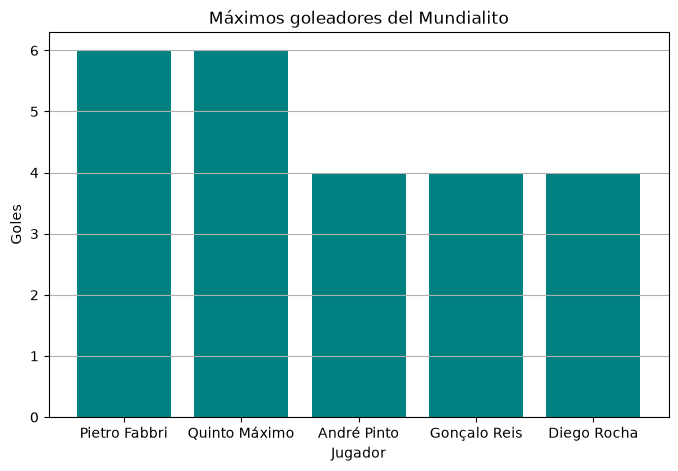

In [12]:
# Gráfica de barras con los 5 máximos goleadores del torneo
top = construir_goleadores()[:5]               # tomamos los 5 mejores goleadores acumulados
nombres = [fila[0] for fila in top]            # lista con los nombres
cantidad = np.array([fila[2] for fila in top]) # arreglo de NumPy con sus goles
plt.figure(figsize=(8,5))                      # creamos la figura
plt.bar(nombres, cantidad, color='teal')       # dibujamos las barras
plt.title('Máximos goleadores del Mundialito') # título de la gráfica
plt.xlabel('Jugador')                          # etiqueta del eje x
plt.ylabel('Goles')                            # etiqueta del eje y
plt.grid(axis='y')                             # cuadrícula horizontal
plt.show()                                     # mostramos la gráfica

## 8. Consulta interactiva
El usuario elige la **fase** (jornadas 1-3, cuartos, semifinales o final) y la **tabla**
que desea ver. Ejecute esta celda y siga las instrucciones.

In [ ]:
# Consulta interactiva: el usuario elige la fase y la tabla que quiere ver
fases = ['Jornada 1','Jornada 2','Jornada 3','Cuartos','Semifinales','Final']        # fases consultables
tipos = ['posiciones','goleadores','asistencias','contribuciones','porteros','todas'] # tablas disponibles

print('¿Qué fase desea consultar?')            # pedimos la fase
for i in range(len(fases)):                     # recorremos las fases
    print(str(i+1) + ') ' + fases[i])           # mostramos cada opción numerada
op_fase = int(input('Número de la fase: ')) - 1 # leemos la opción y restamos 1 para el índice

print('\n¿Qué tabla desea ver?')               # pedimos el tipo de tabla
for i in range(len(tipos)):                      # recorremos los tipos
    print(str(i+1) + ') ' + tipos[i])            # mostramos cada opción numerada
op_tipo = int(input('Número de la tabla: ')) - 1 # leemos la opción y restamos 1 para el índice

fase_elegida = fases[op_fase]                    # nombre de la fase elegida
tipo_elegido = tipos[op_tipo]                    # tipo de tabla elegido
snap = tablas_fase[fase_elegida]                 # recuperamos las tablas de esa fase

print('\nConsulta:', tipo_elegido, 'en', fase_elegida)   # mostramos lo que se va a desplegar
if tipo_elegido == 'todas':                      # si el usuario quiere ver todas las tablas
    imprimir_fase(fase_elegida)                  # imprimimos la fase completa
elif tipo_elegido == 'posiciones':               # si quiere la tabla de posiciones
    if 'posiciones' in snap:                     # solo existe en la fase de grupos
        imprimir_posiciones(snap)                # imprimimos las posiciones por grupo
    else:                                        # en eliminatoria no hay grupos
        print('Esa fase es eliminatoria; mostramos los resultados de la fase:')   # aviso
        print(tabulate(snap['resultados'], headers=['Partido','Marcador'], tablefmt='fancy_grid'))  # resultados
else:                                            # si quiere una tabla individual
    encabezados = {                              # encabezados según el tipo elegido
        'goleadores':     ['Jugador','Nacionalidad','Goles','PJ'],
        'asistencias':    ['Jugador','Nacionalidad','Asist.','PJ'],
        'contribuciones': ['Jugador','Nacionalidad','Goles','Asist.','G+A','PJ'],
        'porteros':       ['Portero','Nacionalidad','Goles recibidos','PJ'],
    }                                            # fin de los encabezados
    imprimir_tabla(snap[tipo_elegido], encabezados[tipo_elegido], 'Tabla de ' + tipo_elegido)  # imprimimos la tabla

¿Qué fase desea consultar?
1) Jornada 1
2) Jornada 2
3) Jornada 3
4) Cuartos
5) Semifinales
6) Final
